# Assignment 6: AI Image Style Transfer


## 1. Introduction

Image style transfer is an AI technique that changes the appearance of one image using the visual characteristics of another image. The main scene or objects can be retained while the image receives an artistic look.

In this assignment, two approaches are explored:

- **CycleGAN** – uses a trained generative model for image-to-image translation.
- **Neural Style Transfer** – uses a pretrained VGG19 network to combine image content and artistic style.


## 2. Objectives

The objectives of this experiment are:

1. Understand the basic idea of AI-based style transfer.
2. Apply a pretrained CycleGAN model to an input image.
3. Create an artistic image using VGG19-based Neural Style Transfer.
4. Observe the difference between the two generated results.
5. Save and display the final outputs.


## 3. Upload Images

Upload two images in Google Colab:

- A **content image**, such as a landscape or photograph.
- A **style image**, such as a painting or artwork.

The first uploaded image is used as the content image and the second one as the style reference for Neural Style Transfer.


In [3]:
from google.colab import files
import os

uploaded = files.upload()

print("\nUploaded files:")
for file in uploaded:
    print(file)

Saving monet.jpg to monet.jpg
Saving mountain.jpg to mountain.jpg

Uploaded files:
monet.jpg
mountain.jpg


In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt

content_file = "mountain.jpg"
style_file = "monet.jpg"

if not os.path.exists(content_file):
    raise FileNotFoundError("mountain.jpg was not uploaded.")

if not os.path.exists(style_file):
    raise FileNotFoundError("monet.jpg was not uploaded.")

content_img = Image.open(content_file).convert("RGB")
style_img = Image.open(style_file).convert("RGB")

print("Content Image :", content_file)
print("Style Image   :", style_file)

Content Image : mountain.jpg
Style Image   : monet.jpg


## 4. Prepare the Input Images

The uploaded files are given simple names so that they can be used easily in the remaining cells.


In [5]:
from pathlib import Path
import shutil

base = Path("/content")
content_path = base / "content_input.jpg"
style_path = base / "style_input.jpg"

shutil.copy(base / content_file, content_path)
shutil.copy(base / style_file, style_path)

print("Input files are ready.")
print(content_path)
print(style_path)


Input files are ready.
/content/content_input.jpg
/content/style_input.jpg


## 5. View the Input Images

Before applying any model, both images are displayed. This helps us see the original content and the artistic reference.


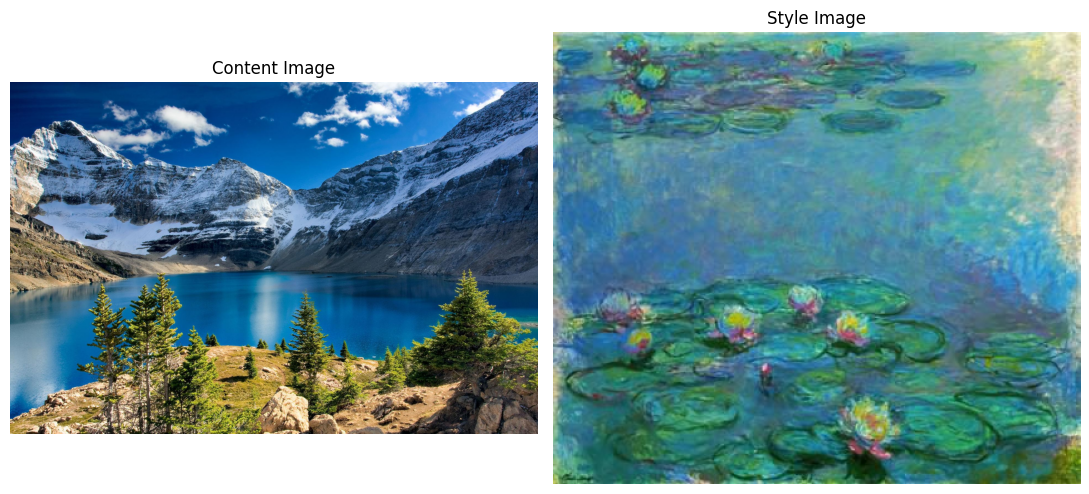

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

photo = Image.open(content_path).convert("RGB")
artwork = Image.open(style_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(photo)
axes[0].set_title("Content Image")
axes[0].axis("off")

axes[1].imshow(artwork)
axes[1].set_title("Style Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 6. Method 1: CycleGAN

CycleGAN is a generative adversarial network designed for image-to-image translation. It can learn visual changes between two image domains without requiring matching image pairs.

For this experiment, a pretrained **Monet-style CycleGAN model** is used. This avoids the need to train a new GAN from the beginning.


In [7]:
import os
from pathlib import Path

repo = Path("/content/pytorch-CycleGAN-and-pix2pix")

if not repo.exists():
    !git clone -q https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

%cd /content/pytorch-CycleGAN-and-pix2pix
!pip install -q dominate visdom

print("CycleGAN setup completed.")


/content/pytorch-CycleGAN-and-pix2pix
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.5 MB/s eta 0:00:00
CycleGAN setup completed.


## 7. Get the Pretrained CycleGAN Model

A pretrained model is downloaded and used for the image transformation. The model produces a Monet-like version of the content image.


In [8]:
%cd /content/pytorch-CycleGAN-and-pix2pix
!bash scripts/download_cyclegan_model.sh style_monet

print("Pretrained model downloaded.")


/content/pytorch-CycleGAN-and-pix2pix
Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-03 14:16:05--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  47.8MB/s    in 0.9s    

2026-10-03 14:16:06 (47.8 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pt

## 8. Run CycleGAN

CycleGAN expects the test image to be placed inside its dataset directory. The content image is copied there and then passed to the pretrained model.


In [9]:
from pathlib import Path
import shutil

test_dir = Path("/content/pytorch-CycleGAN-and-pix2pix/datasets/style_task/testA")
test_dir.mkdir(parents=True, exist_ok=True)

test_image = test_dir / "input.jpg"
shutil.copy(content_path, test_image)

print("Test image:", test_image)


Test image: /content/pytorch-CycleGAN-and-pix2pix/datasets/style_task/testA/input.jpg


In [10]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!python test.py --dataroot ./datasets/style_task --name style_monet_pretrained --model test --no_dropout --preprocess resize

print("CycleGAN processing finished.")


/content/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/style_task         	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
     

## 9. Show the CycleGAN Result

The generated image is loaded from the CycleGAN results folder and displayed with the original image.


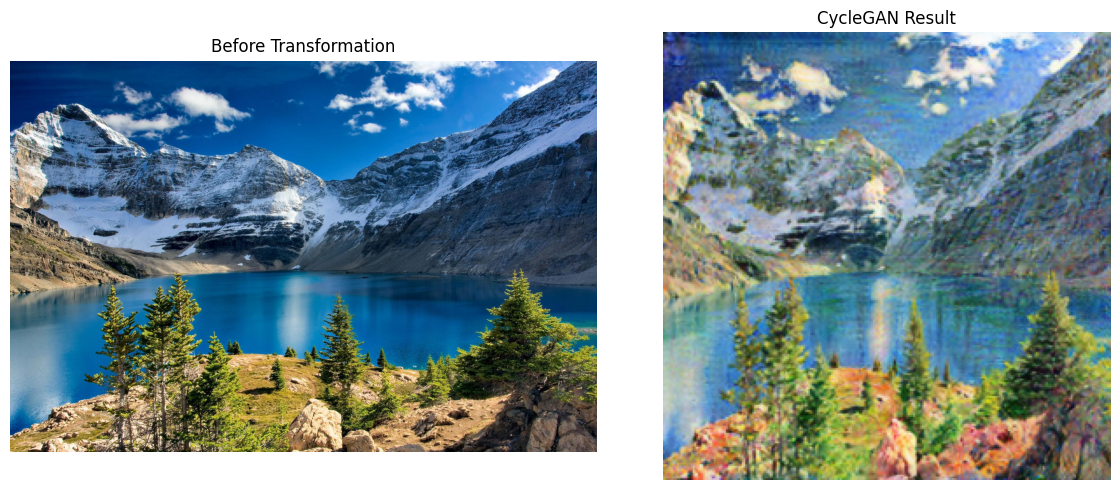

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

result_file = Path(
    "/content/pytorch-CycleGAN-and-pix2pix/results/"
    "style_monet_pretrained/test_latest/images/input_fake.png"
)

if not result_file.exists():
    raise FileNotFoundError("CycleGAN output was not found.")

gan_result = Image.open(result_file).convert("RGB")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(photo)
ax[0].set_title("Before Transformation")
ax[0].axis("off")

ax[1].imshow(gan_result)
ax[1].set_title("CycleGAN Result")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## 10. Method 2: Neural Style Transfer

Neural Style Transfer creates a new image by keeping important content information from one image and matching the visual patterns of another image.

A pretrained VGG19 network is used to obtain these features. The generated image is gradually changed to reduce both content and style differences.


In [12]:
import torch
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

network = models.vgg19(
    weights=models.VGG19_Weights.DEFAULT
).features.to(device).eval()

for parameter in network.parameters():
    parameter.requires_grad = False

print("VGG19 loaded on:", device)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 155MB/s]


VGG19 loaded on: cuda


## 11. Convert Images into Tensors

Both images are resized and converted into tensors. These tensors can then be processed by VGG19.


In [13]:
from torchvision import transforms

resize_to = 512

to_tensor = transforms.Compose([
    transforms.Resize((resize_to, resize_to)),
    transforms.ToTensor()
])

content_tensor = to_tensor(photo).unsqueeze(0).to(device)
style_tensor = to_tensor(artwork).unsqueeze(0).to(device)

print("Content shape:", tuple(content_tensor.shape))
print("Style shape:", tuple(style_tensor.shape))


Content shape: (1, 3, 512, 512)
Style shape: (1, 3, 512, 512)


## 12. Extract VGG19 Features

Some VGG19 layers are used for content information and several layers are used for style information. Style information is represented with Gram matrices.


In [14]:
content_layer = "21"
style_layers = ["0", "5", "10", "19", "28"]

def collect_features(image, wanted_layers):
    saved = {}
    value = image

    for number, layer in network._modules.items():
        value = layer(value)
        if number in wanted_layers:
            saved[number] = value

    return saved

content_features = collect_features(content_tensor, [content_layer])
style_features = collect_features(style_tensor, style_layers)

print("Content feature collected.")
print("Style layers:", style_layers)


Content feature collected.
Style layers: ['0', '5', '10', '19', '28']


In [15]:
def make_gram(feature):
    b, c, h, w = feature.shape
    feature = feature.reshape(c, h * w)
    gram = feature @ feature.t()
    return gram / (c * h * w)

style_targets = {
    layer: make_gram(style_features[layer]).detach()
    for layer in style_layers
}

print("Style representations are ready.")


Style representations are ready.


## 13. Generate the Styled Image

The starting image is a copy of the content image. Adam optimization changes its pixels so that the content remains recognizable while its visual patterns become closer to the style image.


In [18]:
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----- Load images -----
size = 256   # use 512 for the final run
tf = T.Compose([T.Resize((size, size)), T.ToTensor()])
content_tensor = tf(Image.open("/content/mountain.jpg").convert("RGB")).unsqueeze(0).to(device)
style_tensor = tf(Image.open("/content/monet.jpg").convert("RGB")).unsqueeze(0).to(device)

# ----- VGG19 -----
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False

# ----- Layers -----
content_layer = '21'
style_layers = ['0', '5', '10', '19', '28']

# ----- Helper functions -----
def collect_features(img, layers):
    feats, x = {}, (img - mean) / std
    for name, layer in vgg._modules.items():
        x = layer(x)
        if name in layers:
            feats[name] = x
    return feats

def make_gram(t):
    b, d, h, w = t.size()
    f = t.view(b * d, h * w)
    return f @ f.t() / (b * d * h * w)

# ----- Targets -----
content_features = collect_features(content_tensor, [content_layer])
style_targets = {l: make_gram(f) for l, f in collect_features(style_tensor, style_layers).items()}

print("Setup complete. Now run the style transfer cell.")

Using device: cuda
Setup complete. Now run the style transfer cell.


In [21]:
import time

target = content_tensor.clone().requires_grad_(True)

content_strength = 1
style_strength = 1000000   # raise/lower to control style strength

optimizer = torch.optim.Adam([target], lr=0.01)
steps = 200

start = time.time()
for step in range(steps):
    features = collect_features(
        target,
        [content_layer] + style_layers
    )

    loss_content = torch.mean(
        (features[content_layer] - content_features[content_layer]) ** 2
    )

    loss_style = 0
    for layer in style_layers:
        current_gram = make_gram(features[layer])
        loss_style += torch.mean(
            (current_gram - style_targets[layer]) ** 2
        )

    total = (
        content_strength * loss_content
        + style_strength * loss_style
    )

    optimizer.zero_grad()
    total.backward()
    optimizer.step()

    with torch.no_grad():
        target.clamp_(0, 1)

    if (step + 1) % 25 == 0:
        print(
            f"Iteration {step + 1}/{steps} | "
            f"Loss: {total.item():.4f} | "
            f"{time.time() - start:.0f}s"
        )

print("Neural Style Transfer completed.")

Iteration 25/200 | Loss: 14.4205 | 1s
Iteration 50/200 | Loss: 8.3124 | 2s
Iteration 75/200 | Loss: 6.7936 | 3s
Iteration 100/200 | Loss: 6.1886 | 4s
Iteration 125/200 | Loss: 5.8545 | 5s
Iteration 150/200 | Loss: 5.6362 | 6s
Iteration 175/200 | Loss: 5.4760 | 7s
Iteration 200/200 | Loss: 5.3424 | 8s
Neural Style Transfer completed.


## 14. Display and Save the Neural Style Transfer Result


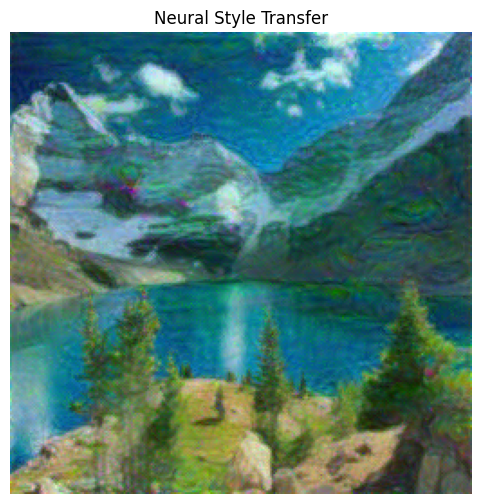

Saved: /content/neural_style_result.jpg


In [22]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

styled_array = (
    target.detach()
    .cpu()
    .squeeze(0)
    .permute(1, 2, 0)
    .numpy()
)

styled_image = Image.fromarray(
    np.uint8(np.clip(styled_array, 0, 1) * 255)
)

nst_file = Path("/content/neural_style_result.jpg")
styled_image.save(nst_file)

plt.figure(figsize=(7, 6))
plt.imshow(styled_image)
plt.title("Neural Style Transfer")
plt.axis("off")
plt.show()

print("Saved:", nst_file)


## 15. Compare Both Methods

The original photograph and the outputs from the two methods are shown together. This makes it easier to observe how the visual appearance changes.


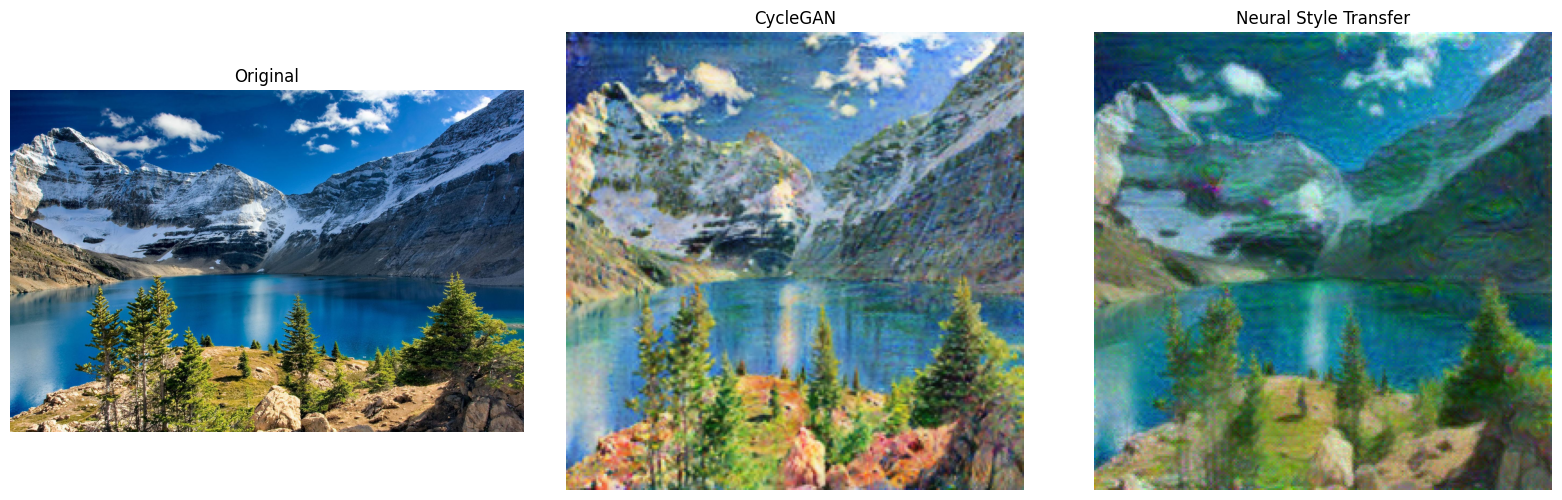

Comparison saved to: /content/style_transfer_comparison.png


In [23]:
fig, panels = plt.subplots(1, 3, figsize=(16, 5))

items = [
    (photo, "Original"),
    (gan_result, "CycleGAN"),
    (styled_image, "Neural Style Transfer")
]

for panel, (picture, title) in zip(panels, items):
    panel.imshow(picture)
    panel.set_title(title)
    panel.axis("off")

plt.tight_layout()
comparison_file = "/content/style_transfer_comparison.png"
plt.savefig(comparison_file, dpi=180, bbox_inches="tight")
plt.show()

print("Comparison saved to:", comparison_file)


## 16. Method Comparison

| Point | CycleGAN | Neural Style Transfer |
|---|---|---|
| Main idea | Image-to-image translation | Content and style feature matching |
| Model used | Pretrained CycleGAN | Pretrained VGG19 |
| Training in this task | No new training | No new model training |
| Input style image | The pretrained model supplies the artistic domain | Directly used as the style reference |
| Main output | Monet-like translated image | Image combining content with style patterns |

## 17. Result

The original photograph keeps its natural appearance. CycleGAN changes the photograph using the visual domain learned by its pretrained Monet model. Neural Style Transfer uses the uploaded artwork to transfer visual patterns while attempting to retain the structure of the original photograph.

## 18. Conclusion

This experiment demonstrated two different AI techniques for changing the appearance of an image. CycleGAN performed image-to-image translation with a pretrained generative model, while Neural Style Transfer used VGG19 features to combine content and artistic style.

The experiment shows that different deep learning methods can create different artistic results from the same source image.
